In [1]:
import glob

import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torchvision.transforms import v2

from architectures.climate_cnn import ClimateCNN
from architectures.swin_transformer import SwinClimateTransformer
from utils.dataloader import load_shards
from utils.koppen_dataset import KoppenDataset
from utils.test_model import test_model

In [2]:
local_pattern = '../data/koppen_shard_part_*.tfrecord.gz'
SEED = 42

# Check if files exist in the local directory
all_files = glob.glob(local_pattern)

if len(all_files) > 0:
    print(f"Found {len(all_files)} shards in local cache.")
else:
    raise FileNotFoundError("Data not found. Please download the dataset using the OneDrive link in the README.")

_, test_files = train_test_split(all_files, test_size=0.1, random_state=SEED)

Found 1500 shards in local cache.


Generating ClimateCNN classification report...
              precision    recall  f1-score   support

          Af       0.62      0.66      0.64       143
          Am       0.62      0.60      0.61       198
          Aw       0.50      0.58      0.54       186
         BWh       0.84      0.77      0.80       209
         BWk       0.61      0.69      0.65       206
         BSh       0.57      0.67      0.61       189
         BSk       0.40      0.35      0.37       197
         Csa       0.60      0.62      0.61       190
         Csb       0.51      0.45      0.48       196
         Csc       0.73      0.80      0.76       183
         Cfa       0.58      0.60      0.59       184
         Cfb       0.63      0.52      0.57       224
         Cfc       0.84      0.93      0.88       200
         Cwa       0.61      0.75      0.67       191
         Cwb       0.56      0.39      0.46       182
         Cwc       0.79      0.86      0.82       188
         Dsa       0.79      0.69 

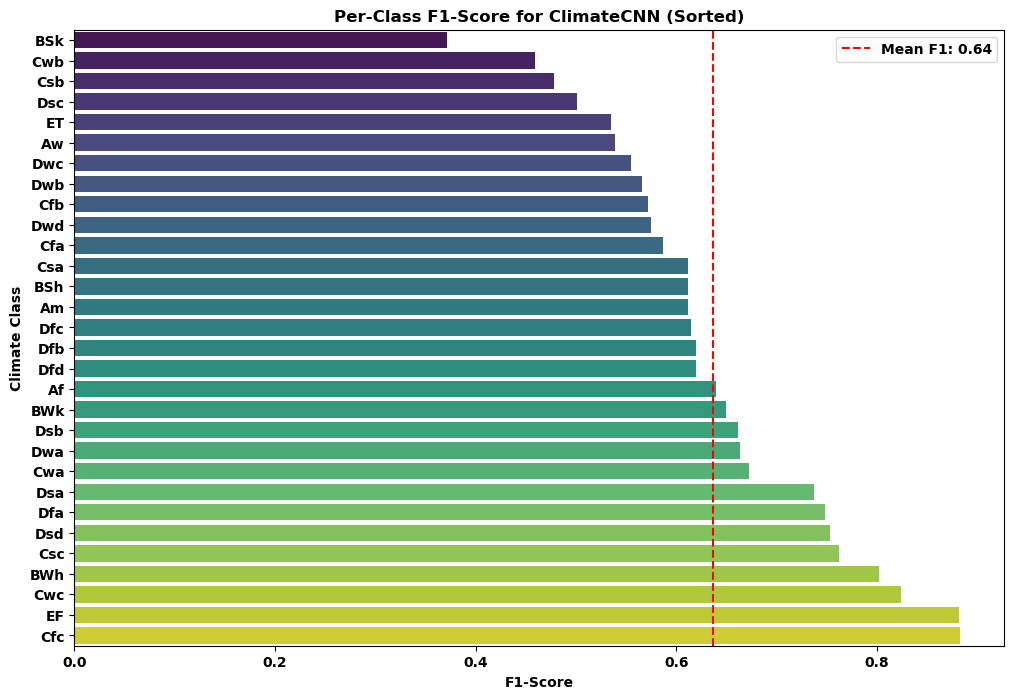

Generating SwinClimateTransformer classification report...
              precision    recall  f1-score   support

          Af       0.61      0.57      0.59       143
          Am       0.53      0.64      0.58       198
          Aw       0.47      0.47      0.47       186
         BWh       0.73      0.69      0.71       209
         BWk       0.59      0.62      0.60       206
         BSh       0.48      0.60      0.53       189
         BSk       0.49      0.35      0.40       197
         Csa       0.48      0.35      0.41       190
         Csb       0.36      0.28      0.31       196
         Csc       0.61      0.72      0.66       183
         Cfa       0.40      0.51      0.45       184
         Cfb       0.39      0.52      0.45       224
         Cfc       0.76      0.93      0.83       200
         Cwa       0.55      0.47      0.51       191
         Cwb       0.46      0.36      0.40       182
         Cwc       0.66      0.77      0.71       188
         Dsa       0.5

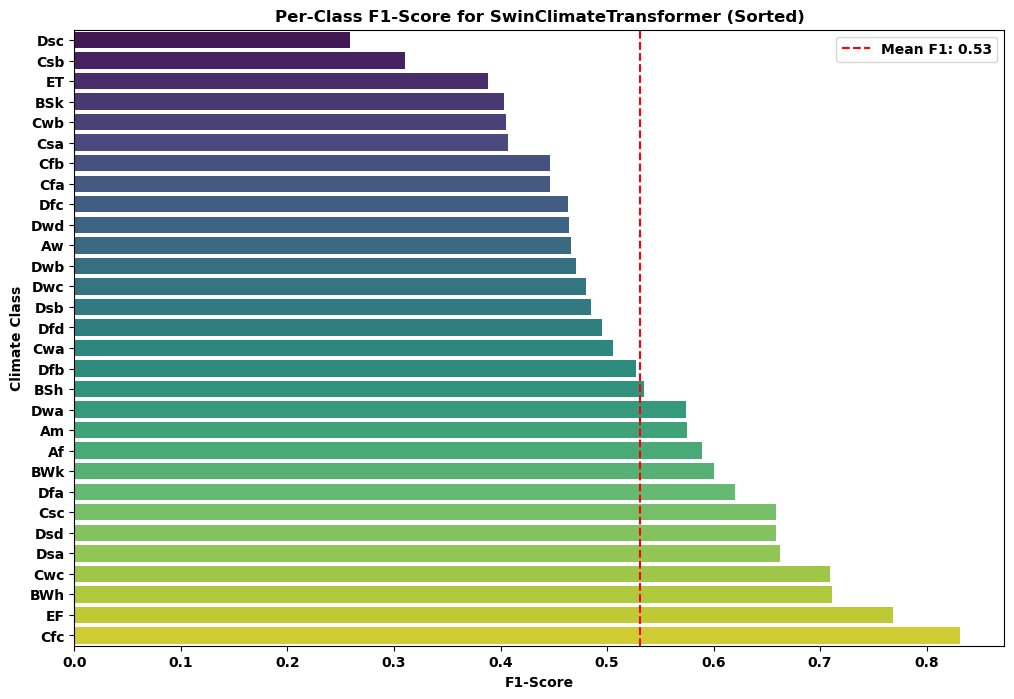

In [5]:
clip_val = 4000

# Minimal transforms to perform on CPU
cpu_transforms = v2.Compose([
    # Clip to the same range used for stats
    v2.Lambda(lambda x: torch.clamp(x, 0, clip_val)),
    v2.ToDtype(torch.float32, scale=False),
])

batch_size = 256
test = load_shards(test_files, batch_size=batch_size, is_training=False)
test_loader = DataLoader(
    KoppenDataset(test, cpu_transforms), batch_size=None, pin_memory=True
)

# Test CNN and ViT models on the full dataset
print("Generating ClimateCNN classification report...")
test_model(ClimateCNN, 'final_models/cnn_checkpoint.pth', test_loader)
print("Generating SwinClimateTransformer classification report...")
test_model(SwinClimateTransformer, 'final_models/transformer_checkpoint.pth', test_loader)